DHANSHREE | 221A033 | 08 | BE-AIDS

# Upper Confidence Bound (UCB1): Selects actions based on both the estimated reward and uncertainty.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

step 1 : to create mutlti ARM Bandit class

In [ ]:
class MultiArmedBandit:
    def __init__(self, k=10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)  # True rewards for each arm
        self.best_arm = np.argmax(self.q_true)

    def pull_arm(self, arm):
        return np.random.normal(self.q_true[arm], 1)  # Reward with some noise

Step 2 : To create agent class

In [ ]:
class Agent:
    def __init__(self, bandit, strategy = "epsilon_greedy", epsilon=0.1, c = 2 ):
        self.bandit = bandit
        self.strategy = strategy
        self.epsilon = epsilon
        self.c = c
        self.k = bandit.k
        self.Q = np.zeros(self.k) # Estimated rewards
        self.N = np.zeros(self.k) # Number of times each arm was pulled

    def select_action(self, t):
        if self.strategy == "epsilon_greedy":
            if np.random.rand() < self.epsilon:
                return np.random.randint(self.k) #Random action
            else:
                return np.argmax(self.Q) #Exploit best - known action

        elif self.strategy == "ucb1":
            if 0 in self.N: # Ensure all arms are tried at least once
                return np.argmin(self.N)
            return np.argmax(self.Q + self.c * np.sqrt(np.log(t+1) / self.N))
        # elif self.strategy == "thompson_sampling":
        # samples = np.random.normal(self.Q, 1/ (self.N+1)) # Sample from belief
        # return np.argmax(samples)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action] # Incremental mean update

Implements Epsilon-Greedy, and UCB1 exploration agents

Updates Q-values using the incremental mean method.

step3 : To create function to estimate average reward for each strategy

In [ ]:
def run_strategy(k=10, steps=2000, runs=250, strategies=["epsilon_greedy", "ucb1"]):
    avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}
    for strategy in strategies:
        for run in range(runs):
            bandit = MultiArmedBandit(k)
            agent = Agent(bandit, strategy)
            rewards = np.zeros(steps)
            for t in range(steps):
                action = agent.select_action(t)
                reward = bandit.pull_arm(action)
                agent.update(action, reward)
                rewards[t] = reward
            avg_rewards[strategy] += rewards / runs
    return avg_rewards

Runs multutiple trial each strategy


Step 4 : To run the experiment to estimate average reward

In [ ]:
# Run the experiment
strategies = ["epsilon_greedy", "ucb1"]
results = run_strategy()

In [ ]:
results.keys()

dict_keys(['epsilon_greedy', 'ucb1'])

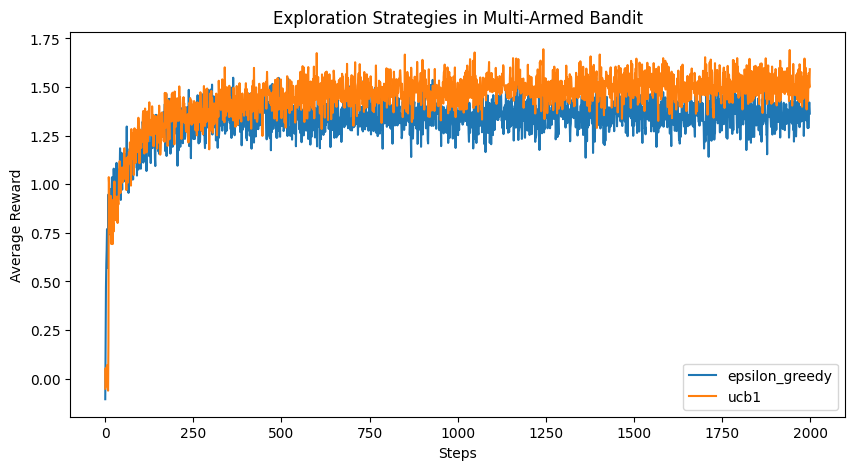

In [ ]:
#Plot the results
plt.figure(figsize=(10, 5))
for strategy, rewards in results.items():
    plt.plot(rewards, label=strategy)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.title("Exploration Strategies in Multi-Armed Bandit")
plt.show()

Exploration strategies in multi Armed bandit

Observations
Initial Phase (First 100 Steps)

Both strategies start with low rewards and improve over time.
UCB1 shows a faster initial learning rate, meaning it finds better arms more quickly.

Middle Phase (100-500 Steps)

UCB1 consistently outperforms Epsilon-Greedy with slightly higher rewards.

Epsilon-Greedy fluctuates more, as it keeps exploring randomly with probability e E

Final Phase (500-1000 Steps)

UCB1 stabilizes at a slightly higher average reward.

Epsilon-Greedy keeps fluctuating due to its continued exploration.

LiCote confidance.hocad eunlaration lande to hatter Inne form avninitation

1 For short duration either of the algorithms can be used

2 But fOR LONG duration UCB1 must be used